In [6]:
from pathlib import Path
import sys

root_dir = Path.cwd().parent
sys.path.append(str(root_dir))

In [ ]:
%load_ext autoreload
%autoreload 2

import warnings
import random
import os
import torch
import pandas as pd
import numpy as np
import pytorch_lightning as pl
from torch.utils.data import DataLoader
from sklearn.linear_model import LinearRegression
from src.ingest_data import ingest_options_data, ingest_intraday_data, ingest_daily_prices, ingest_risk_free_rate_data
from src.transform_data import SplineTransformer, VolatilitySmileDataset, get_training_data_parkinson_vol, get_garch_dataset
from src.garch import GARCH
from src.dpmm import DPMM
from src.backtest import simulate_trading_strategy, compute_sharpe_ratio, compute_total_returns
from src.utils import LOGGER
from src.plots import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
def seed_everything(seed=124):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
seed_everything()

warnings.filterwarnings("ignore")

## Data Ingestion

Ingest:
- 4-Week Treasury Bill Secondary Market Rate (DTB4WK) for Sharpe Ratio calculation
- S&P 500 (SPY) option chain for DPMM volatility smile modeling
- S&P 500 (SPY) intraday price for GARCH volatility prediction
- S&P 500 (SPY) daily price for backtesting

Split train and test data on 2021-05-06

In [ ]:
# Train/test split date
split_date = '2021-05-06'

# Ingest risk-free rate
df_risk_free_rate = ingest_risk_free_rate_data('DTB4WK')

# Ingest structured daily SPY option chain data
df_option_chain = ingest_options_data('SPY', df_risk_free_rate)
# Train/test split
df_option_chain_train = df_option_chain.query("date <= @split_date")
df_option_chain_test = df_option_chain.query("date > @split_date")

# Test option dates
option_dates_test = df_option_chain_test['date'].sort_values().unique()

# Ingest structured intraday SPY price data
df_intraday = ingest_intraday_data('SPY')

# Ingest structured daily SPY price data
df_daily = ingest_daily_prices('SPY')
# Train/test split
df_daily_train = df_daily.query("date <= @split_date")
df_daily_test = df_daily.query("date > @split_date")

# Date index test data
date_index_test = df_daily_test.index

2026-01-30 16:12:32,439 | src.utils | INFO > Retrieved risk free rate data
2026-01-30 16:12:32,457 | src.utils | INFO > Connected to MySQL server
2026-01-30 16:13:44,422 | src.utils | INFO > Retrieved daily SPY option chain data from MySQL server
2026-01-30 16:13:45,305 | src.utils | INFO > Retrieved intraday SPY price data
2026-01-30 16:13:45,677 | src.utils | INFO > Connected to MySQL server
2026-01-30 16:14:03,672 | src.utils | INFO > Retrieved daily SPY price data from MySQL server


## Data Processing

Create dataset for DPMM:
- construct the grid knots $\{ j_i \}_i$ of log-moneyness based on empirical quantiles to ensure uniform data coverage
- initialize B-splines $X$ over the grid knots
$$
    X_{i,0}(\cdot) = \mathbb{1}_{[j_i, j_{i+1}]}(\cdot) \qquad \qquad X_{i,j}(\cdot) = \frac{\cdot - j_i}{j_{i+j} - j_i} X_{i,j-1}(\cdot) + \frac{j_{i+j+1} - \cdot}{j_{i+j+1} - j_{i+1}} X_{i+1,j-1}(\cdot), \quad j>0
$$
- interpolate implied volatility $\text{IV}_t$ at 30-day expiry for day $t$ using expiries right before ($T_1$) and after ($T_2$) the target ($T^* = \frac{30}{365}$)
$$
    \text{IV}_t = \text{IV}_t({T^*}) = \sqrt{\frac{\omega T_1 \text{IV}_t({T_1}) + (1-\omega)T_2 \text{IV}_t({T_2})}{T^*}}, \quad \omega = \frac{T^* - T_1}{T_2 - T_1}
$$

Compute daily realized volatility $s_t$ for day $t$ from high-frequency intraday log-returns $\{r_{t,n}\}_n$
$$
    s_t = \sqrt{252} \sqrt{ \sum_{n} r_{t,n}^2 + \left( \ln \left( \frac{\text{open}_t}{\text{close}_t} \right) \right)^2 }
$$

In [ ]:
# Number of moneyness levels (quantiles)
M = 22

# Target expiry
target_time_to_expiry = 30

# Create spline transformer
quantiles = np.linspace(0, 1, M-1)
spline_transformer = SplineTransformer(df_option_chain_train['log_moneyness'], quantiles, degree = 3)
D = spline_transformer.get_num_basis()

# Create dataset
dataset_dpmm_train = VolatilitySmileDataset(df_option_chain_train, spline_transformer, target_time_to_expiry)
dataset_dpmm_test = VolatilitySmileDataset(df_option_chain_test, spline_transformer, target_time_to_expiry)

# Initialize dataloader
dataloader_train = DataLoader(dataset_dpmm_train, batch_size=len(dataset_dpmm_train), shuffle=True)
dataloader_test = DataLoader(dataset_dpmm_test, batch_size=len(dataset_dpmm_test), shuffle=False)

# Training data for linear regression model of observed volatility ~ Parkinson volatility
parkinson_vol, observed_vol, vol_train_dates = get_training_data_parkinson_vol(df_intraday, df_daily_train)

2026-01-30 16:14:08,276 | src.utils | INFO > Spline transformer initialized: 
 >D=12 basis elements 
 >Grid=[-0.33029582 -0.25521325 -0.16361621 -0.10534233 -0.06164345 -0.01964533
  0.          0.02039608  0.05922108  0.09756155  0.1571608   0.21047415]
2026-01-30 16:14:08,333 | src.utils | INFO > Dataset initialized: T=193 trading days
2026-01-30 16:14:08,506 | src.utils | INFO > Dataset initialized: T=772 trading days


## Initialize Models

### Dirichlet Process Mixture Model

The volatility smile $Y_t$ for day $t$ is the graph of implied volatility at 30-day expiry $\text{IV}_t$ as a function of log-moneyness $l$
$$
    Y_t = \{ (l, y) : l \in \mathbb{R}, \  y = \text{IV}_t(l) \}.
$$
Given the fixed B-spline basis matrix $X$, the volatility smile is modeled as a random draw from a Huber distribution to ensure smoothness and robustness against outliers
$$
    Y_t \, | \, \beta_t; X,\tau \stackrel{\text{iid}}{\sim} \text{Huber}(X\beta_t, \tau),
$$
with $\tau$ an hyperparameter.
The spline coefficients $\beta_t$ active for day $t$ are drawn from a discrete probability measure 
$$
    \beta_t \stackrel{\text{iid}}{\sim} P.
$$
A Dirichlet Process (DP) prior governs the mixture weights
$$
    P \sim \text{DP}(\alpha, G_0).
$$
The base measure for the Dirichlet Process prior is chosen as a multivariate Normal distribution with prior mean initialized from the data
$$
    G_0 = \text{Norm}(\mu, I).
$$

Under this specification, the full likelihood for the volatility smile $Y_t$ over the discrete grid knots $\{ j_1,\ldots,j_M \}$ of log-moneyness is
$$
    p(Y_t \, | \, \beta_t, \pi ; X, \tau) = \sum_{k=1}^K \pi_k \prod_{i=1}^M p(y_{t}(j_i) \, | \beta_t; X, \tau),
$$
where $\pi = (\pi_1,\ldots,\pi_K)$ are the cluster weights from the DPMM prior.

### GARCH

Log-returns $r_t$ are assumed to evolve as
$$
    r_t = \mu + \epsilon_t,
$$
where $\epsilon_t = \sigma_t z_t$ with $z_t \sim \text{Norm}(0,1)$ and variance defined by the GARCH-X recursion
$$
    \sigma_t^2 = \omega + \alpha \epsilon_{t-1}^2 + \beta \sigma_{t-1}^2 + \gamma S_{t-1}.
$$
The exogenous variable $S$ is a variance proxy based on Parkinson volatility $P$
$$
    S_t = (b_0 + b_1 P_t)^2, \qquad P_t = \sqrt{ \frac{1}{4 \ln(2)} \left( \ln\left(\frac{\text{high}_t}{\text{low}_t}\right) \right)^2 },
$$
where the coefficients $b_0, b_1$ are estimated by regressing high-frequency realized volatility $s_t^2$ on Parkinson volatility
$$
    s_t^2 = b_0 + b_1 P_t.
$$

In [ ]:
# Number of clusters
K = 2

# Initialize prior means
prior_mean_init = dataset_dpmm_train.get_prior_mean_init(method='kmeans', K=K)

# Initialize DPMM
dpmm = DPMM(
    K=K, 
    D=D, 
    num_samples=len(dataset_dpmm_train),
    prior_mean_init=prior_mean_init
)

# Initialize linear regression model to predict observed volatility given Parkinson volatility proxy
lr = LinearRegression(fit_intercept=False)

# Initialize GARCH
garch = GARCH()

## Train models

In [13]:
"""
Models training
"""
# Train DPMM
trainer = pl.Trainer(max_epochs=50, accelerator="auto")
trainer.fit(dpmm, train_dataloaders=dataloader_train)
LOGGER.info(f"DPMM model fitted")

# Fit linear regression model: observed volatility ~ Parkinson volatility
lr = lr.fit(parkinson_vol, observed_vol)
LOGGER.info(f"Linear regression model fitted. Estimated coeffcient: {lr.coef_[0]:.4f}. R-Squared: {lr.score(parkinson_vol, observed_vol):.4f}")

# Fit GARCH
log_returns_train, var_hat_train, garch_train_dates = get_garch_dataset(df_daily_train.reset_index(), lr)
garch = garch.fit(log_returns_train, var_hat_train)
LOGGER.info(f"GARCH model fitted. Estimated parameters: {garch.params}")

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name         | Type | Params | Mode | FLOPs
-----------------------------------------------------
  | other params | n/a  | 51     | n/a  | n/a  
-----------------------------------------------------
51        Trainable params
0         Non-trainable params
51        Total params
0.000     Total estimated model params size (MB)
0         Modules in train mode
0         Modules in eval mode
0         Total Flops


Epoch 49: 100%|██████████| 1/1 [00:00<00:00, 130.75it/s, v_num=0, train_loss=-3.58e+3]

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 1/1 [00:00<00:00, 70.88it/s, v_num=0, train_loss=-3.58e+3] 
2026-01-30 16:14:17,053 | src.utils | INFO > DPMM model fitted
2026-01-30 16:14:17,055 | src.utils | INFO > Linear regression model fitted. Estimated coeffcient: 1.4321. R-Squared: 0.6336
2026-01-30 16:14:17,070 | src.utils | INFO > GARCH model fitted. Estimated parameters: [ 0.03634113  0.02174018  0.02299851  0.64538987 10.08835813]


## Posterior Inference & Forecasts

### Regime Detection
Given the trained DPMM, the posterior probability that day $t$ belongs to regime $k$ is
$$
    \hat\phi_{t,k} = \frac{\exp\{\ell_{t,k}\}}{\sum_{j=1}^K \exp\{\ell_{t,j}\}}, \qquad \ell_{t,k} = \log \hat\pi_k + \log p(Y_t \, | \, \hat\beta_t, \hat\pi ; X, \tau).
$$

### Forecast Volatility

Given the estimated GARCH-X parameters $\hat\omega,\hat\alpha,\hat\beta,\hat\gamma$ and the long-run persistance
$$
    \hat\rho = \hat\alpha + \hat\beta + \hat\gamma \, \text{median}(\{S_t\}_t),
$$
volatility is forecasted over a the future time horizon of $H$ days as
$$
    \hat\sigma_{t,H} = \sqrt{\frac{252}{H}} \sqrt{H \frac{\hat\omega}{1-\hat\rho} + \left(\sigma_t^2 - \frac{\hat\omega}{1-\hat\rho}\right) \frac{\hat\rho(1-\hat\rho^H)}{1-\hat\rho} }.
$$

In [ ]:
# Compute posterior regime probabilities for each trading day
dpmm.eval()
with torch.no_grad():
    full_batch = next(iter(dataloader_test))
    posterior_probabilities = dpmm.get_posterior_probabilities(full_batch['x'], full_batch['y'])
    index_panic_cluster = dpmm.get_index_panic_cluster(spline_transformer)

df_regimes = pd.DataFrame(
    posterior_probabilities, 
    index=option_dates_test, 
    columns=[f'cluster_{k}' for k in range(posterior_probabilities.shape[1])]
)
# Add and impute missing trading days
df_regimes = df_regimes.reindex(date_index_test).ffill()
LOGGER.info(f"Posterior regimes probabilities computed. Panic cluster index: {index_panic_cluster}")

# Variance ratio
variance_ratio = garch.get_ratio(log_returns_train, var_hat_train)

# Forecast volatility
log_returns_test, var_hat_test, garch_test_dates = get_garch_dataset(df_daily_test.reset_index(), lr)
variance_path_test = garch.get_conditional_variance_path(log_returns_test, var_hat_test)
vol_hat = garch.forecast(variance_path_test, variance_ratio, time_horizon=21)
df_vol = pd.Series(vol_hat, index = date_index_test, name = 'vol_hat')
LOGGER.info(f"Volatility forecasted")

# ATM implied volatility
df_atm_iv = dataset_dpmm_test.get_atm_iv()
# Add and impute missing trading days
df_atm_iv = df_atm_iv.reindex(date_index_test).ffill()
LOGGER.info(f"ATM implied volatility recovered")

NameError: name 'dpmm' is not defined

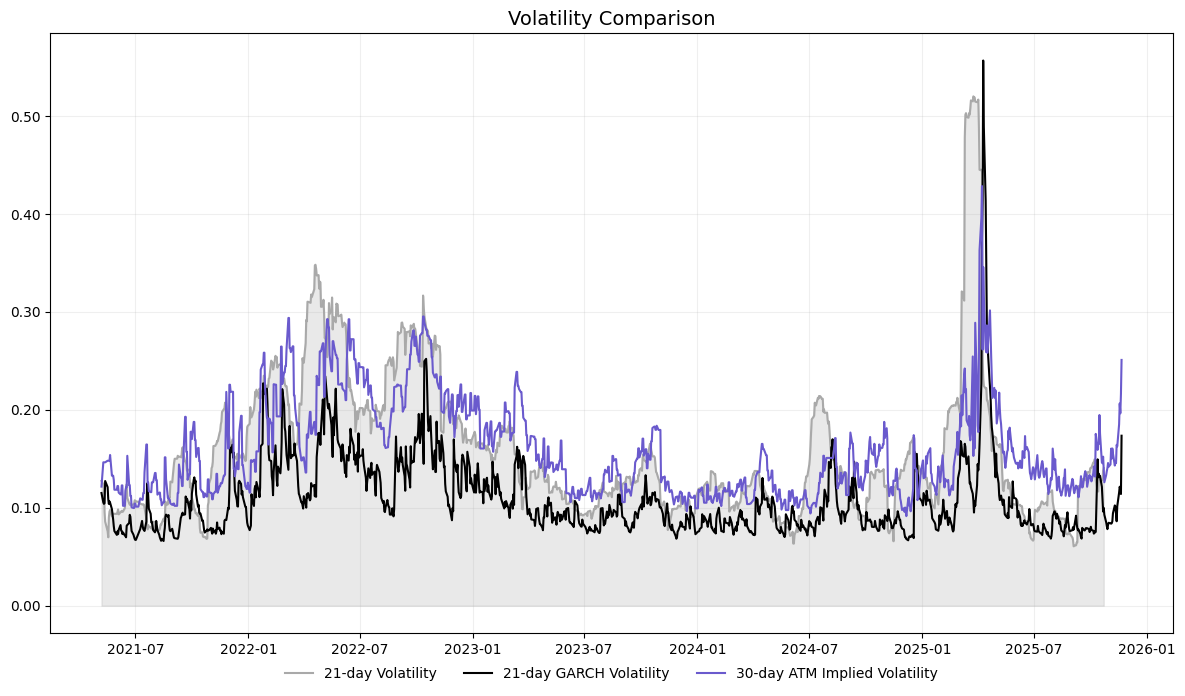

In [ ]:
garch_vol_forecast = pd.Series(vol_hat / 100, index = date_index_test, name = 'garch_vol_forecast')

observed_var = (df_daily_test['close'].pct_change() ** 2) * 252
realized_vol = np.sqrt(observed_var.rolling(window=21).mean()).shift(-21).rename('vol')

plot_volatility(garch_vol_forecast, df_atm_iv/100, realized_vol)

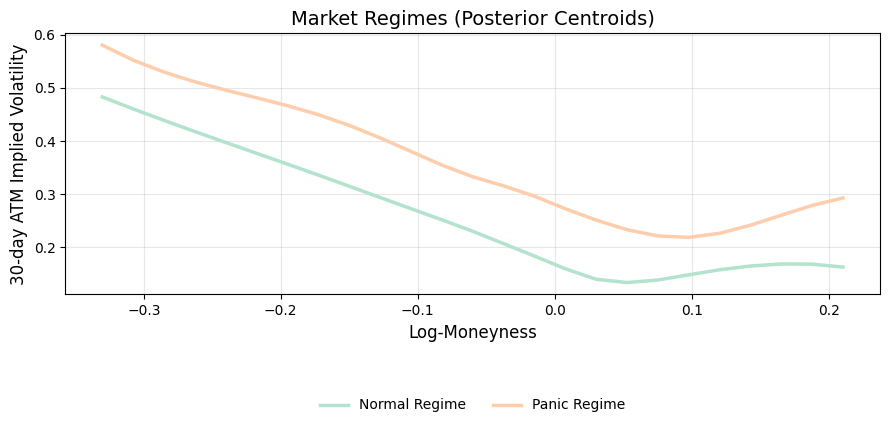

In [ ]:
plot_cluster_centroids(dpmm, spline_transformer, labels = ['Normal Regime', 'Panic Regime'])

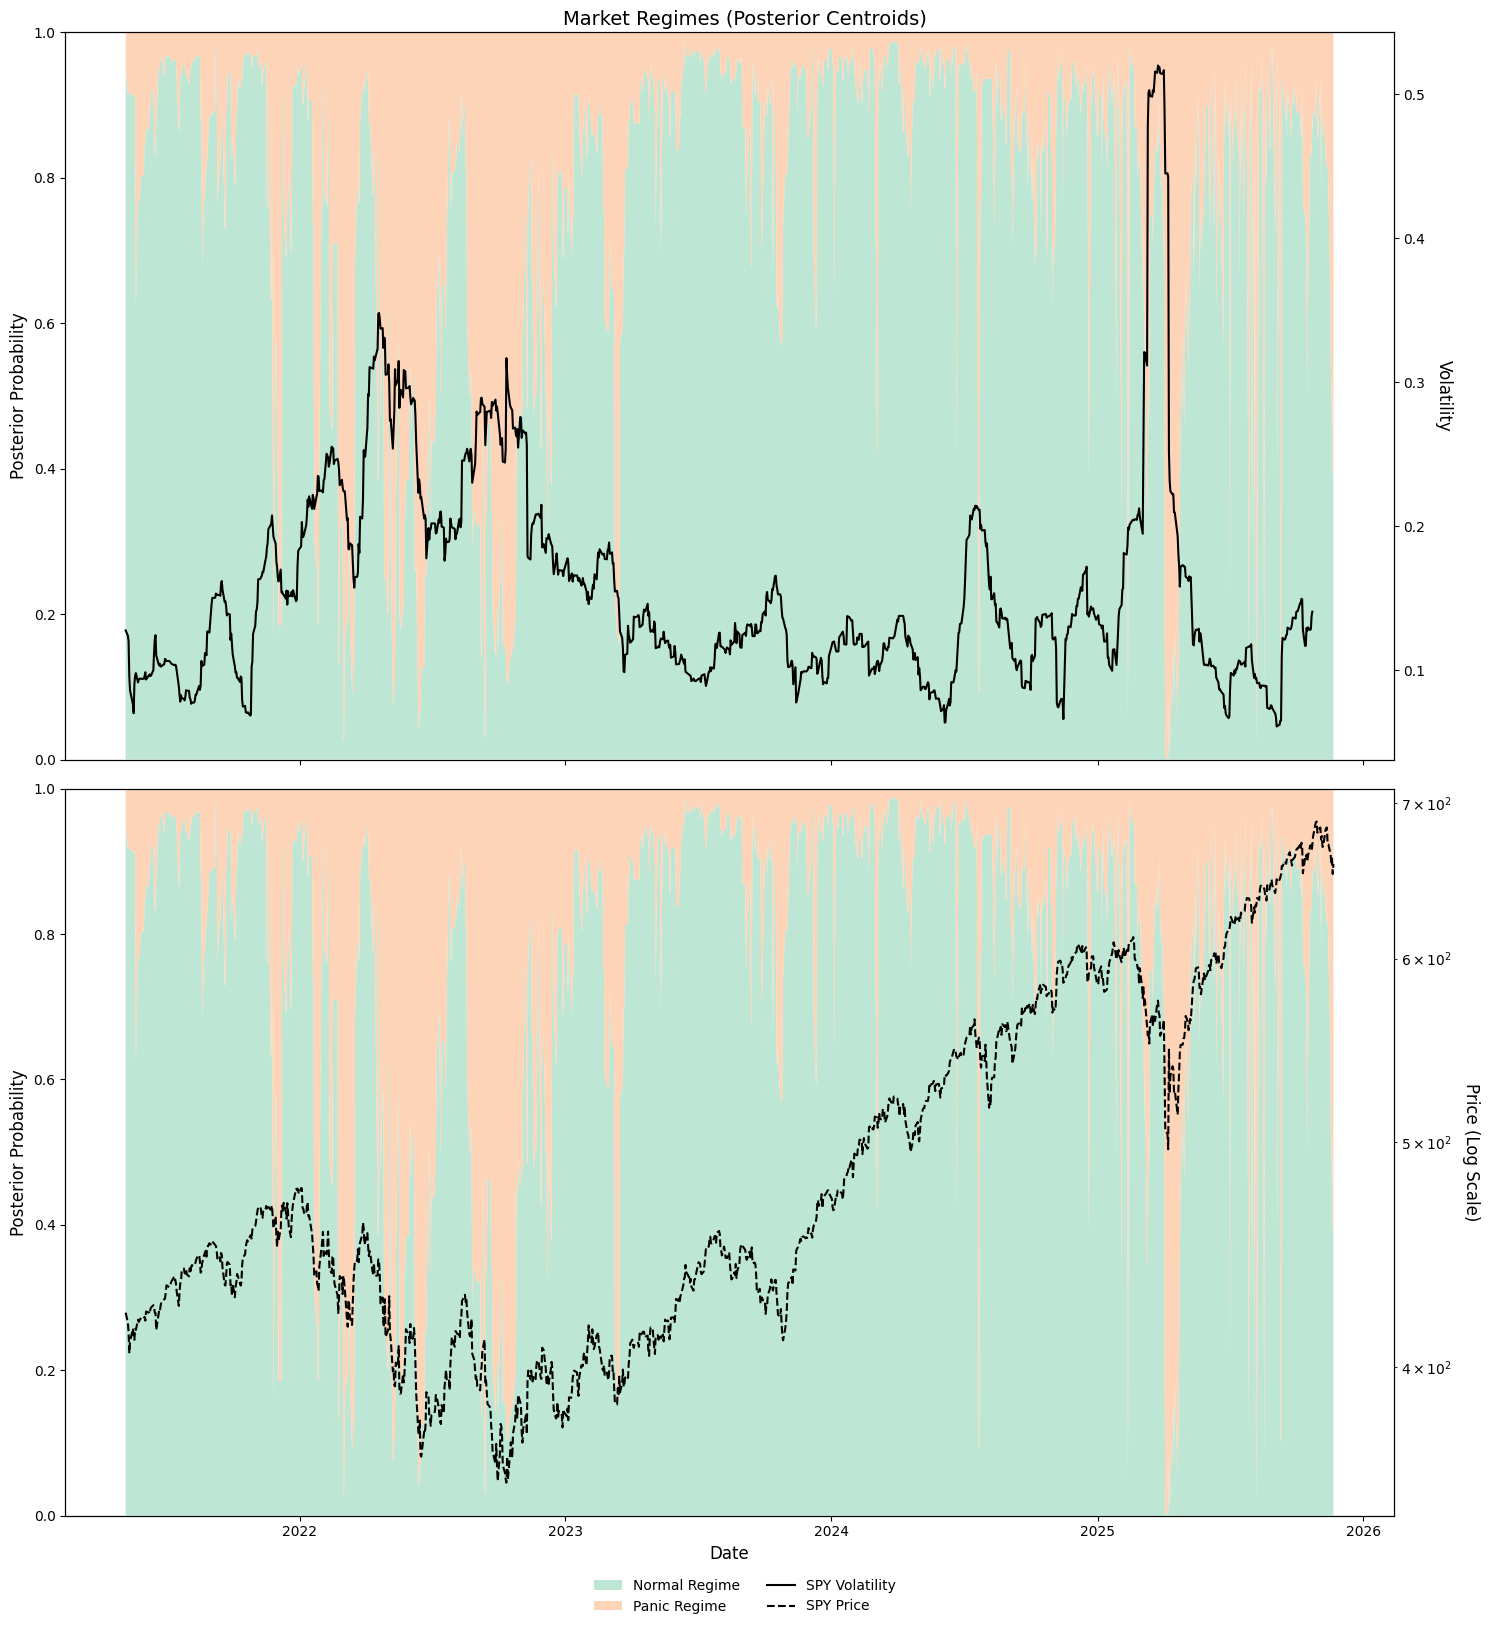

In [ ]:
plot_cluster_probabilities(
    df_regimes.loc[date_index_test], 
    realized_vol, 
    df_daily_test.loc[date_index_test, 'close'], 
    rolling_window=1, 
    labels = ['Normal Regime', 'Panic Regime']
)

## Backtesting

- Long SPY strategy: buy and hold SPY 
- Naive Short Volatility strategy: daily delta-hedged short volatility position on SPY 30-day options
- Conditional Short Volatility strategy: daily delta-hedged short volatility position on SPY 30-day options with trade executed on day $t$ only if
    - there is a large enough edge on volatility premium: $\text{IV}_t - \hat\sigma_{t,21} > \delta_{\sigma}$
    - there is a high probability of being in a normal market regime: $\hat\phi_{t,\text{Normal}} > \delta_{\phi}$

In [ ]:
# Edge threshold
edge_threshold = 1.0

# Probability threshold
prob_threshold = 0.75

# Cluster index
cluster_index = 0

# Risk free rate
risk_free_rate = df_risk_free_rate.set_index('date').reindex(date_index_test)['r'] / 252

# Dataframe backtesting
df_backtest = pd.concat([df_regimes, df_atm_iv, df_vol, df_daily_test['close']], axis=1)
LOGGER.info(f"Dataframe backtesting created with {df_backtest.shape[0]} trading days")

# Simulate trading strategy
backtest_results = simulate_trading_strategy(df_backtest, cluster_index = cluster_index, edge_threshold=edge_threshold, prob_threshold=prob_threshold)

2026-01-30 16:15:01,075 | src.utils | INFO > Dataframe backtesting created with 1136 trading days


In [ ]:
total_returns = {
    'long': compute_total_returns(df_daily_test['close']),
    'naive': compute_total_returns(backtest_results['naive_curve']),
    'conditional': compute_total_returns(backtest_results['conditional_curve'])
}
print_returns(total_returns)

sharpe_ratios = {
    'long': compute_sharpe_ratio(df_daily_test['return'], risk_free_rate),
    'naive': compute_sharpe_ratio(backtest_results['naive_daily_return'], risk_free_rate),
    'conditional': compute_sharpe_ratio(backtest_results['conditional_daily_return'], risk_free_rate),
}
print_sharpes(sharpe_ratios)


Returns:
 > Long SPY: 56.124%
 > Naive Short Volatility: -111.785%
 > Conditional Short Volatility: 159.076%

Sharpe Ratio:
 > Long SPY: 0.472
 > Naive Short Volatility: -0.528
 > Conditional Short Volatility: 1.099


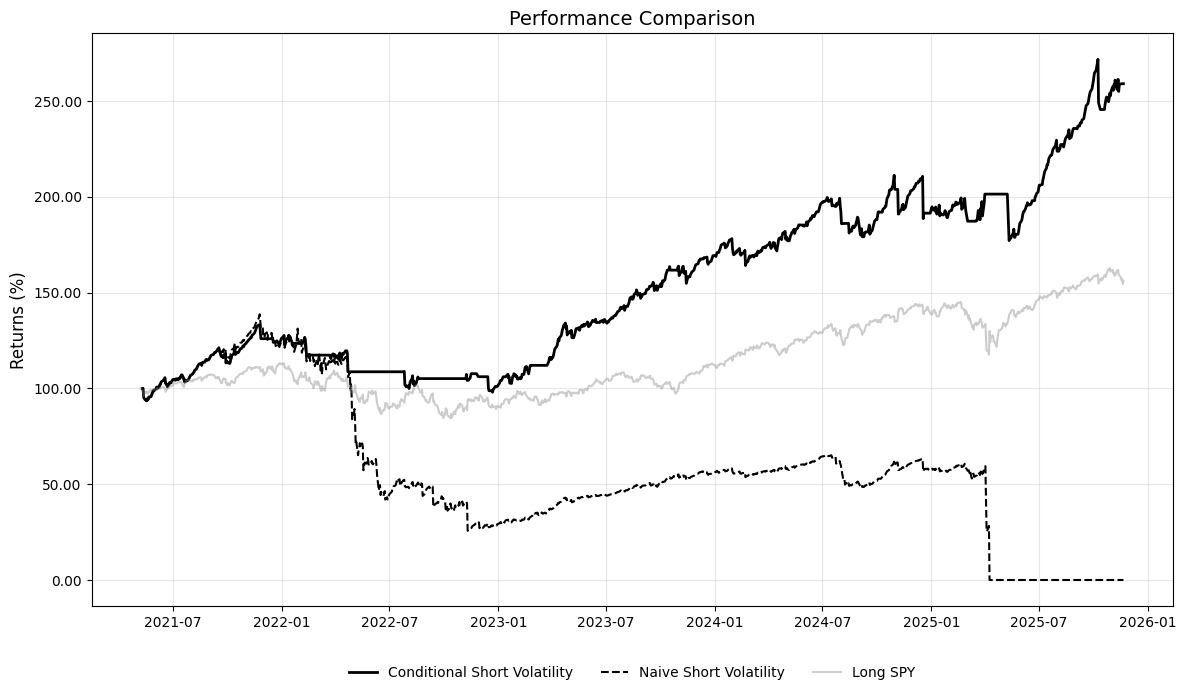

In [ ]:
plot_performance(backtest_results, df_daily_test)

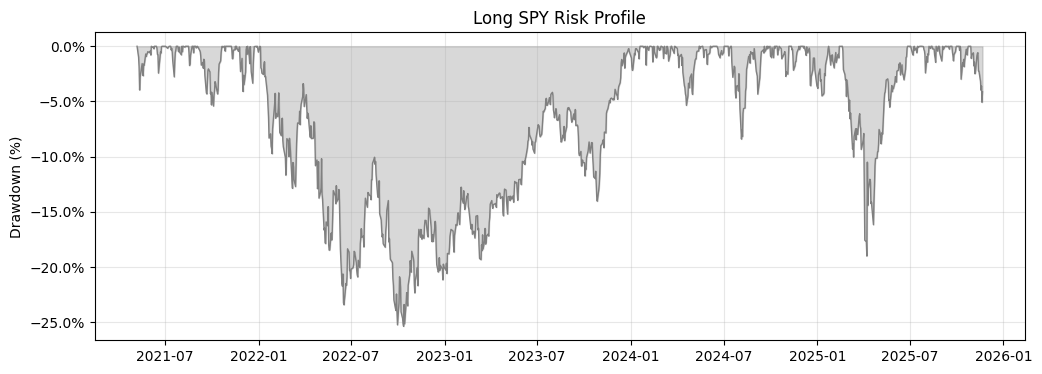

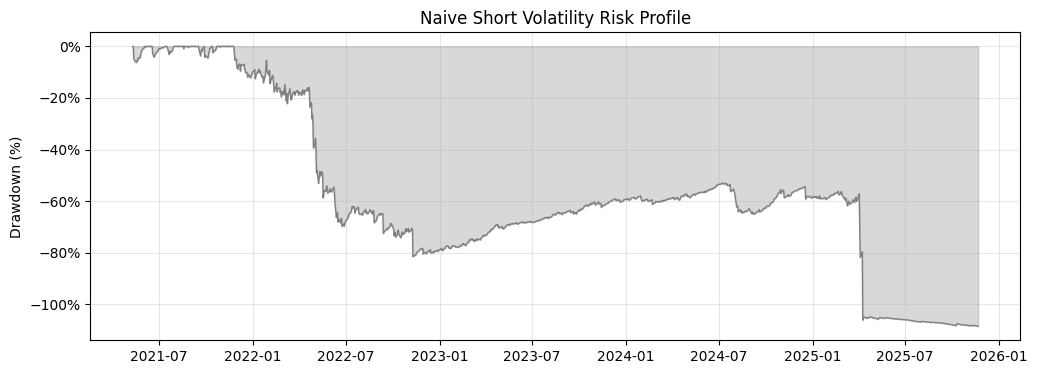

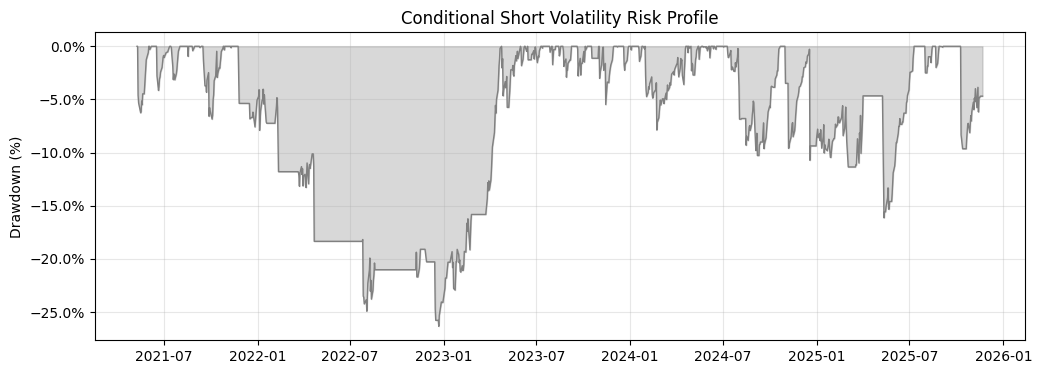

In [26]:
plot_drawdown(df_daily_test['close'], 'Long SPY')
plot_drawdown(backtest_results['naive_curve'], 'Naive Short Volatility')
plot_drawdown(backtest_results['conditional_curve'], 'Conditional Short Volatility')

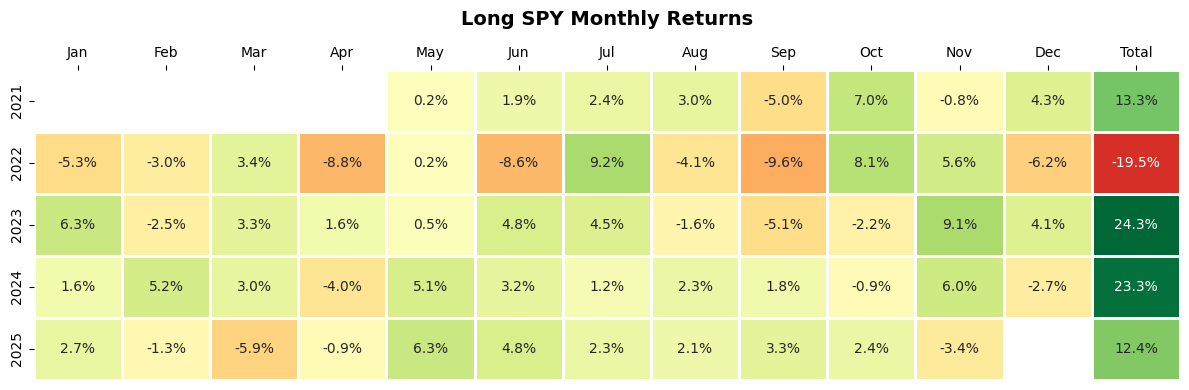

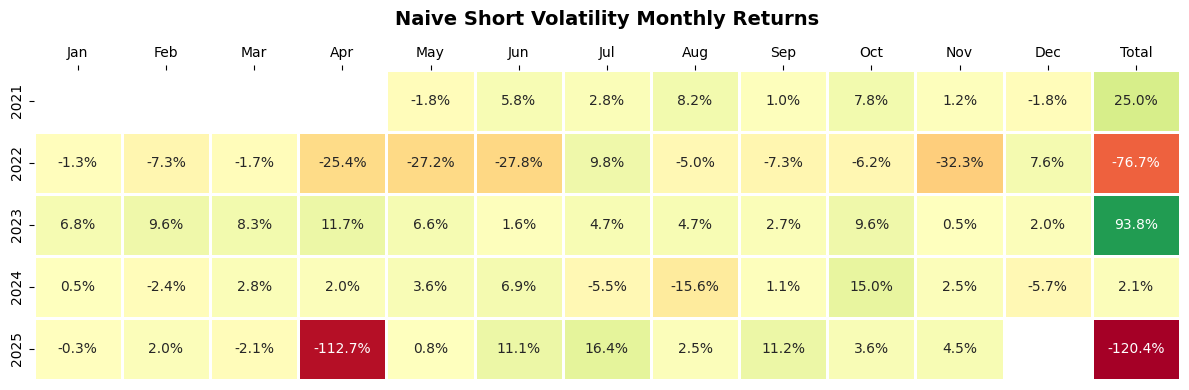

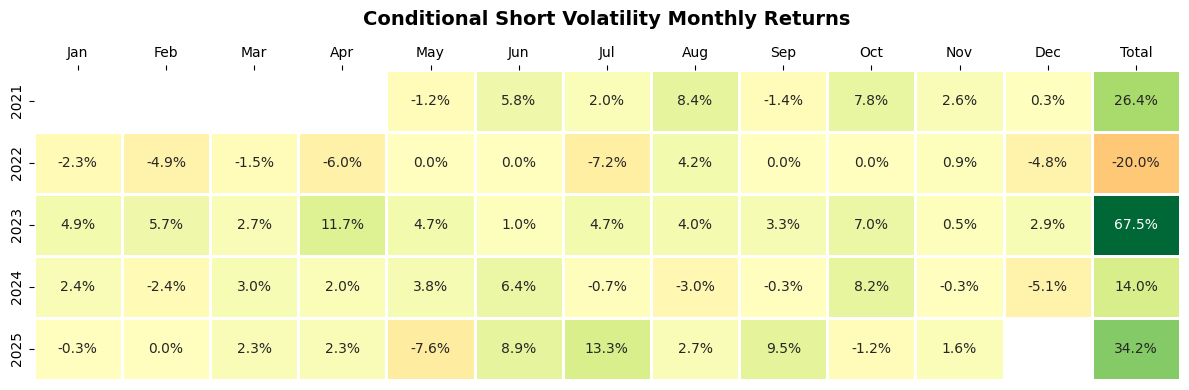

In [27]:
monthly_grid_long = plot_monthly_returns(df_daily_test['return'], 'Long SPY')
monthly_grid_naive = plot_monthly_returns(backtest_results['naive_daily_return'], 'Naive Short Volatility')
monthly_grid_conditional = plot_monthly_returns(backtest_results['conditional_daily_return'], 'Conditional Short Volatility')

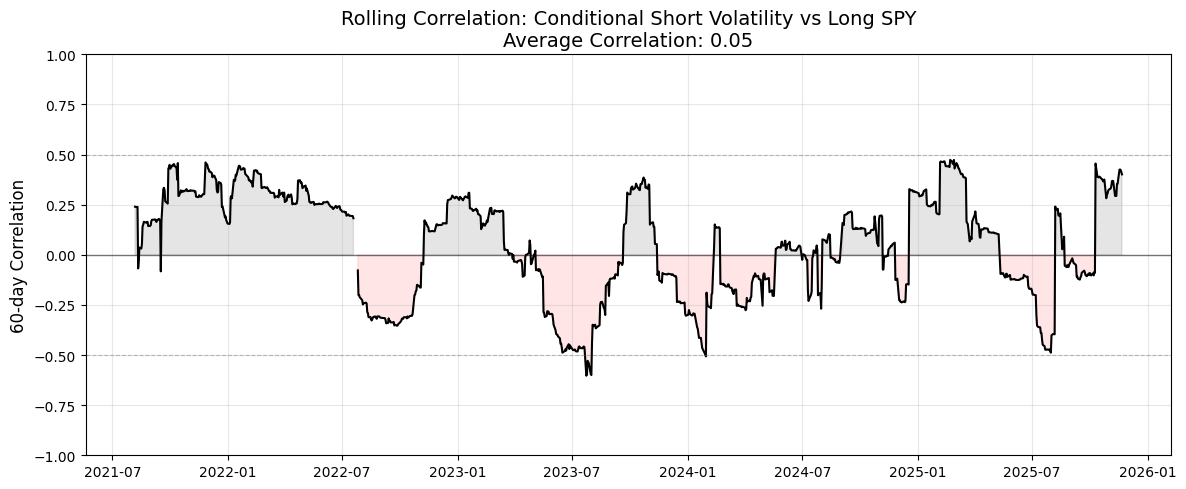

In [ ]:
plot_rolling_correlation(backtest_results, df_daily_test, window=60)